# Simulation False Positive Rate Across Demographic Groups

This notebook builds a simulation pipeline to study fairness in machine learning,
following the structure taught in class:

1. Data Collection (via a simulator)
2. Data Processing
3. Fitting Models
4. Testing the Quality of the Fit
5. Drawing Conclusions

We create two environments:

- **Fair World:** No demographic bias affects measurements.
- **Biased World:** A measurement bias inflates glucose readings for women.

We then train identical ML models in each world and compare False Positive Rates
(FPR) across genders.

This lets us test whether FPR is a useful fairness metric.


In [99]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


## Simulation (Data Collection)

We sample variables according to a causal structure:

HbA1c → Glucose_true → Diabetes
And Glucose_true + noise → Glucose_measured

In the biased world, gender adds a measurement shift:

Gender → MeasurementBias → Glucose_measured


In [100]:
def simulate_world(n=6000, bias_amount=0, seed=None):
    if seed is not None:
        np.random.seed(seed)

    gender = np.random.choice(["Male","Female"], size=n)

    # weak predictor (so model cannot perfectly classify)
    hba1c = np.random.normal(5.5, 0.7, size=n)

    # very noisy physiology -> class overlap -> realistic FP/FN
    glucose_true = 5 * hba1c + np.random.normal(0, 50, size=n)

    # class boundary intentionally low to create balanced classes
    diabetes = (glucose_true > 70).astype(int)

    # measurement noise
    noise = np.random.normal(0, 40, size=n)

    # BIAS: females get glucose inflation
    measurement_bias = np.where(gender == "Female", bias_amount, 0)

    glucose_measured = glucose_true + noise + measurement_bias

    return pd.DataFrame({
        "Gender": gender,
        "HbA1c": hba1c,
        "Glucose_true": glucose_true,
        "Glucose_measured": glucose_measured,
        "Diabetes": diabetes
    })


In [101]:
Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [102]:
def compute_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)


In [103]:
def evaluate_fprs(df):
    X_train, X_test, y_train, y_test = prepare_data(df)

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    test_df = df.iloc[y_test.index].copy()
    test_df["Pred"] = preds

    fprs = {}
    for g in ["Male","Female"]:
        sub = test_df[test_df["Gender"] == g]
        fprs[g] = compute_fpr(sub["Diabetes"], sub["Pred"])

    return fprs


In [104]:
# generate worlds
fair_df   = simulate_world(bias_amount=0, seed=42)
biased_df = simulate_world(bias_amount=40, seed=42)  # strong bias

# evaluate
fair_fprs   = evaluate_fprs(fair_df)
biased_fprs = evaluate_fprs(biased_df)

print("Fair world FPR:", fair_fprs)
print("Biased world FPR:", biased_fprs)


Fair world FPR: {'Male': np.float64(0.04479578392621871), 'Female': np.float64(0.056439942112879886)}
Biased world FPR: {'Male': np.float64(0.00922266139657444), 'Female': np.float64(0.08683068017366136)}


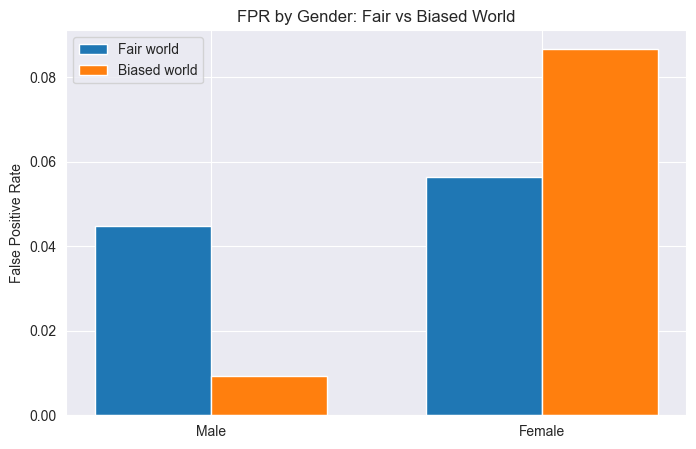

In [105]:
labels = ["Male","Female"]
fair_vals   = [fair_fprs[g]   for g in labels]
biased_vals = [biased_fprs[g] for g in labels]

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - w/2, fair_vals, w, label="Fair world")
plt.bar(x + w/2, biased_vals, w, label="Biased world")

plt.xticks(x, labels)
plt.ylabel("False Positive Rate")
plt.title("FPR by Gender: Fair vs Biased World")
plt.legend()
plt.show()
